In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt
from pathlib import Path

In [16]:
first_step = ep["steps"][0]
print("First step keys:", list(first_step.keys()))
for k, v in first_step.items():
    if not isinstance(v, (list, dict)):
        print(f"  {k}: {type(v).__name__} = {repr(v)}")
    else:
        print(f"  {k}: {type(v).__name__}")
        if isinstance(v, dict):
            for sub_k, sub_v in v.items():
                if not isinstance(sub_v, (list, dict)):
                    print(f"    {sub_k}: {type(sub_v).__name__} = {repr(sub_v)}")
                else:
                    print(f"    {sub_k}: {type(sub_v).__name__}")

AttributeError: 'list' object has no attribute 'keys'

In [21]:
import json
from pathlib import Path

EPISODE_DIR = Path("../data/episodes")

# Take the first JSON file
sample_file = next(EPISODE_DIR.glob("*.json"))
print(f"Sample file: {sample_file}")

with open(sample_file, "r", encoding="utf-8") as f:
    ep = json.load(f)

# Print the top‑level keys
print("Top-level keys:")
for k in ep.keys():
    print(f"  {k}: type={type(ep[k]).__name__}", end="")
    if isinstance(ep[k], list):
        print(f", length={len(ep[k])}")
    else:
        print()
first_step = ep["steps"][0]
print("Type of first step:", type(first_step).__name__)
print("Length:", len(first_step))
print("First element of step:", first_step[0])
print("\nRewards:", ep["rewards"])

for i, step in enumerate(ep["steps"][:3]):
    print(f"\n--- Step {i} ---")
    for j, entry in enumerate(step):
        print(f"  Entry {j}:")
        for k, v in entry.items():
            if not isinstance(v, (list, dict)):
                print(f"    {k}: {v}")
            else:
                print(f"    {k}: {v}")

Sample file: ..\data\episodes\76555298.json
Top-level keys:
  configuration: type=dict
  description: type=str
  id: type=str
  info: type=dict
  module_version: type=str
  name: type=str
  rewards: type=list, length=2
  schema_version: type=int
  specification: type=dict
  statuses: type=list, length=2
  steps: type=list, length=54
  title: type=str
  version: type=str
Type of first step: list
Length: 2
First element of step: {'action': {'submission': -1}, 'info': {}, 'observation': {'remainingOverageTime': 12, 'step': 0}, 'reward': 0, 'status': 'ACTIVE'}

Rewards: [-1, 1]

--- Step 0 ---
  Entry 0:
    action: {'submission': -1}
    info: {}
    observation: {'remainingOverageTime': 12, 'step': 0}
    reward: 0
    status: ACTIVE
  Entry 1:
    action: {'submission': -1}
    info: {}
    observation: {'remainingOverageTime': 12}
    reward: 0
    status: ACTIVE

--- Step 1 ---
  Entry 0:
    action: {'actionString': None, 'generate_returns': [], 'status': 'OK; Setup step; model not c

AttributeError: 'list' object has no attribute 'keys'

In [23]:
import json
import numpy as np
from pathlib import Path

# --------------------------------------------------
#  CONFIGURATION
# --------------------------------------------------
EPISODE_DIR = Path("../data/episodes")
OUTPUT_PATH = Path("../data/processed/train_state_value.npz")

ROWS, COLS = 9, 10

def make_move(board, col, player):
    """Place a piece for `player` (0 or 1) in column `col`, return new board and row."""
    new_board = board.copy()
    for r in range(ROWS-1, -1, -1):
        if new_board[0, r, col] == 0 and new_board[1, r, col] == 0:
            new_board[player, r, col] = 1.0
            return new_board, r
    raise ValueError(f"Column {col} is full")

def board_to_perspective(board, current_player):
    """
    board is (2,9,10) with channel0=player0, channel1=player1.
    Rotate so channel0 = current_player's pieces.
    """
    if current_player == 0:
        return board.copy()
    else:
        flipped = np.zeros_like(board)
        flipped[0] = board[1]
        flipped[1] = board[0]
        return flipped

def extract_value_targets(episode):
    """
    Process one episode, return arrays of states (2,9,10) and values.
    States are from the perspective of the player to move.
    """
    # Determine outcome: rewards [r0, r1]
    r0, r1 = episode["rewards"]
    if r0 > r1:
        outcome = 1    # player 0 (x) wins
    elif r0 < r1:
        outcome = -1   # player 1 (o) wins
    else:
        outcome = 0    # draw

    # Reconstruct moves from step entries.
    # Actions appear as `submission` in entry 0 when player is active,
    # or entry 1. But we can simply parse `observationString.board` from
    # step entries to see the state after each action.
    # Simpler: we'll walk and collect states before each move.
    
    states = []
    values = []
    board = np.zeros((2, ROWS, COLS), dtype=np.float32)  # channel0=player0, channel1=player1
    current_player = 0  # starts with player 0 (x)

    # step 0 is setup (no move), skip or use empty board as initial state?
    # We'll skip step 0 because it's before any action.
    # For step 1 onward, the `submission` field indicates the move that was made.
    for step_idx, step_entries in enumerate(episode["steps"]):
        # Try to find the acting player's entry.
        # Look for an entry with 'action' and 'submission' != -1
        acting_entry = None
        for entry in step_entries:
            subm = entry.get("action", {}).get("submission", -1)
            if subm != -1 and subm is not None:
                acting_entry = entry
                break
        if acting_entry is None:
            continue  # setup step or terminal step with no action
        
        # The move that was just made by the previous player.
        # But whose turn is it? The observation after the move tells us.
        # Let's instead use the board from the entry and compute perspective.
        # Actually, we'll rely on observationString to get board after move,
        # then deduce state before move by removing the piece.
        # However, it's easier: record state BEFORE move, then apply move.
        
        # Collect state before this move:
        state_from_perspective = board_to_perspective(board, current_player)
        states.append(state_from_perspective)
        
        # Compute value target for this state
        if outcome > 0:
            val = 1.0 if current_player == 0 else -1.0
        elif outcome < 0:
            val = -1.0 if current_player == 0 else 1.0
        else:
            val = 0.0
        values.append(val)
        
        # Apply the move
        col = acting_entry["action"]["submission"]
        board, _ = make_move(board, col, current_player)
        
        # Switch players
        current_player = 1 - current_player
    
    # After all moves, the board is terminal (no more moves possible).
    # We could also add the terminal state but it's not needed for value training.
    
    return np.array(states), np.array(values)

# ---------- Process all episodes ----------
all_states = []
all_values = []

for json_file in sorted(EPISODE_DIR.glob("*.json")):
    with open(json_file, "r", encoding="utf-8") as f:
        ep = json.load(f)
    
    try:
        states, values = extract_value_targets(ep)
        all_states.extend(states)
        all_values.extend(values)
    except Exception as e:
        print(f"Skipping {json_file.name}: {e}")

# ---------- Save ----------
all_states = np.array(all_states, dtype=np.float32)
all_values = np.array(all_values, dtype=np.float32)

print(f"Total states: {len(all_states)}")
print(f"Value distribution: win={(all_values==1).sum()}, draw={(all_values==0).sum()}, loss={(all_values==-1).sum()}")
np.savez_compressed(OUTPUT_PATH, states=all_states, values=all_values)
print(f"Saved to {OUTPUT_PATH}")


Total states: 121518
Value distribution: win=57872, draw=7380, loss=56266
Saved to ..\data\processed\train_state_value.npz


In [24]:
data_path = Path("../data/processed/train_state_value.npz")
data = np.load(data_path)
states = data["states"]    # shape (N, 2, 9, 10)
values = data["values"]    # shape (N,)   → 1 (win), 0 (draw), -1 (loss)

print(f"Loaded {len(states)} states")
print(f"Value distribution: win={(values==1).sum()}, draw={(values==0).sum()}, loss={(values==-1).sum()}")

Loaded 121518 states
Value distribution: win=57872, draw=7380, loss=56266


In [25]:
class ValueNet(nn.Module):
    """
    Takes a board of shape (2, 9, 10) and outputs a single scalar
    representing the expected outcome from the current player's perspective.
    """
    def __init__(self):
        super().__init__()
        # Input: 2 channels
        self.conv1 = nn.Conv2d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Residual block
        self.res_conv = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.res_bn = nn.BatchNorm2d(128)
        
        # Value head: global average pooling + FC
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1)   # output tanh → range [-1, 1]
        
    def forward(self, x):
        # Convolutional stack
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        
        # Residual connection
        residual = x
        x = torch.relu(self.res_bn(self.res_conv(x)))
        x = x + residual
        
        # Value head
        x = self.global_pool(x)            # shape (batch, 128, 1, 1)
        x = x.view(x.size(0), -1)          # (batch, 128)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                    # (batch, 1)
        return torch.tanh(x).squeeze(-1)   # shape (batch,)

In [26]:
# Convert to PyTorch tensors
X = torch.tensor(states, dtype=torch.float32)
y = torch.tensor(values, dtype=torch.float32)  # targets are in [-1, 0, 1]

# Train / validation split
split = int(0.8 * len(X))
train_dataset = TensorDataset(X[:split], y[:split])
val_dataset = TensorDataset(X[split:], y[split:])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Epoch 01 | Train loss: 0.8993 | Val loss: 0.8606
Epoch 02 | Train loss: 0.8332 | Val loss: 1.0754
Epoch 03 | Train loss: 0.7491 | Val loss: 1.0086
Epoch 04 | Train loss: 0.6822 | Val loss: 1.0299
Epoch 05 | Train loss: 0.6349 | Val loss: 1.0971
Epoch 06 | Train loss: 0.6030 | Val loss: 1.0852
Epoch 07 | Train loss: 0.5787 | Val loss: 1.1515
Epoch 08 | Train loss: 0.5573 | Val loss: 0.9644
Epoch 09 | Train loss: 0.5443 | Val loss: 1.1363
Epoch 10 | Train loss: 0.5264 | Val loss: 1.0745
Epoch 11 | Train loss: 0.5175 | Val loss: 1.0736
Epoch 12 | Train loss: 0.5079 | Val loss: 1.1229
Epoch 13 | Train loss: 0.4971 | Val loss: 1.1030
Epoch 14 | Train loss: 0.4914 | Val loss: 1.0615
Epoch 15 | Train loss: 0.4808 | Val loss: 1.1700
Epoch 16 | Train loss: 0.4760 | Val loss: 1.2195
Epoch 17 | Train loss: 0.4703 | Val loss: 1.1349
Epoch 18 | Train loss: 0.4693 | Val loss: 1.1652
Epoch 19 | Train loss: 0.4611 | Val loss: 1.1365
Epoch 20 | Train loss: 0.4573 | Val loss: 1.1768
Epoch 21 | Train los

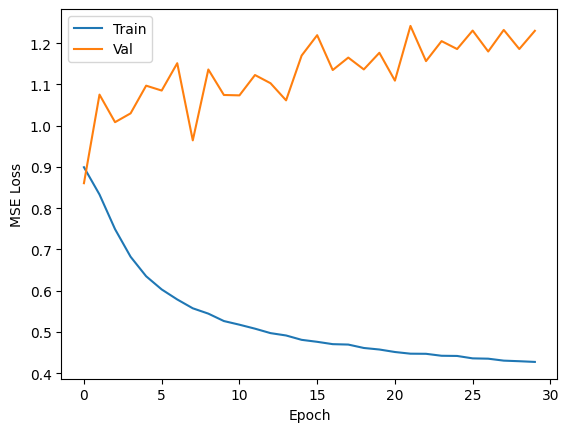

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ValueNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()   # regression on [-1, 1] works well

epochs = 30
train_losses, val_losses = [], []

for epoch in range(1, epochs+1):
    # Training
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_train = total_loss / len(train_dataset)
    train_losses.append(avg_train)
    
    # Validation
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_val += loss.item() * xb.size(0)
    avg_val = total_val / len(val_dataset)
    val_losses.append(avg_val)
    
    print(f"Epoch {epoch:02d} | Train loss: {avg_train:.4f} | Val loss: {avg_val:.4f}")

# Plot losses
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [28]:
# Quick evaluation: accuracy (sign match)
model.eval()
correct = 0
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        # Treat prediction as win/loss if sign matches
        sign_pred = torch.sign(preds)
        sign_true = torch.sign(yb)
        correct += (sign_pred == sign_true).sum().item()
print(f"Sign accuracy on validation: {correct / len(val_dataset):.3f}")

# Export to ONNX
onnx_path = "../ml/models/value_net.onnx"
dummy_input = torch.randn(1, 2, 9, 10, device=device)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["board"],
    output_names=["value"],
    opset_version=11,
    dynamic_axes={"board": {0: "batch_size"}}
)
print(f"Model saved to {onnx_path}")

# Quick test with ONNX Runtime
ort_session = ort.InferenceSession(onnx_path)
test_input = dummy_input.cpu().numpy()
out = ort_session.run(None, {"board": test_input})[0]
print("ONNX output shape:", out.shape)

Sign accuracy on validation: 0.515
Model saved to ../ml/models/value_net.onnx
ONNX output shape: (1,)
